# Exploratory Data Analysis

## Initial Exploration

With the objective of understanding the data structure regarding the STAR-TPM Glioblastoma gene expression dataset, this present stage of the investigation will follow the standard *Exploratory Data Analysis* methodology for uncovering the contents of the dataset.

The following code will help us understand:

- Number of samples (patients)
- Number of variables (genes)
- Available clinical variables

In [5]:
import pandas as pd

df = pd.read_csv('../../data/star_data/rnaseq_stpm_transposed.csv')

# 1. Count the number of samples
num_samples = len(df)

# 2. Count the total number of variables
num_variables = len(df.columns)

# 3. Identify and count available clinical variables
# Note: In UCSC Xena datasets, gene expression columns are usually numeric, 
# while clinical variables are often non-numeric or specifically labeled.
clinical_vars = df.select_dtypes(exclude=['float64', 'int64']).columns.tolist()
num_clinical_vars = len(clinical_vars)

print(f"Number of samples: {num_samples}")
print(f"Total number of variables: {num_variables}")
print(f"Number of clinical variables: {num_clinical_vars}")
print(f"Clinical variables found: {clinical_vars}")

X = df.drop('Patient_Barcode', axis=1)


Number of samples: 175
Total number of variables: 60661
Number of clinical variables: 1
Clinical variables found: ['Patient_Barcode']


As we can see, there are n=175 patient  samples in the dataset, with p=60,660 variables, each of which correspond to a specific RNA sequence gene expressions. The only clinical variable that was found in the dataset is `Ensembl_ID`, which pertains to the unique identifier for each of the n gene expressions, and as such, will not be included in the extent of this project.

According to the National Cancer Institute pertaining to the U.S. Department of Health and Human Services, the creation of this unique sequence expression was derived from the [mRNA Analysis Pipeline](https://docs.gdc.cancer.gov/Data/Bioinformatics_Pipelines/Expression_mRNA_Pipeline/), which is a quantification analysis pipeline that measures gene level expression with the [STAR](https://github.com/alexdobin/STAR/blob/master/doc/STARmanual.pdf) aligner code, which uses TPM (Transcripts Per Million) values to map RNA sequence reads. This method is creates reliable and normalized measures for gene expressions, which are optimal for visualization via unsupervised learning methods accross samples. 

Furthermore, it is worth stating that the present dataset, and the one which will be used in the rest of the research investigation is exactly the same as the original [GDC TCGA Glioblastoma Dataset](https://xenabrowser.net/datapages/?cohort=GDC%20TCGA%20Glioblastoma%20(GBM)&removeHub=https%3A%2F%2Fxena.treehouse.gi.ucsc.edu%3A443), with the difference in this dataset being that the present has been transposed so as to align the data with bioinformatics and machine learning standards. Most python libraries focused on machine learning expect columns and rows to represent samples and features/genes respectively, and *TCGA GBM* datasets structure their datasets the other way around.

### Missing data, outliers and general data distribution

With the objective of further understanding the present dataset, the following stage of the *exploratory analysis* phase of the project will be centered around finding the general distribution of the data, as well as finding missing data and outliers. 

In accordance to level of difficulty, we now proceed to check for missing data in the dataframe.

In [2]:
import numpy as np


def analyze_missing_data(df):
    """
    Counts missing data and calculates the percentage for each column.
    Returns a DataFrame sorted by the highest percentage of missing values.
    """
    missing_counts = df.isnull().sum()
    missing_percentages = (df.isnull().sum() / len(df)) * 100
    
    missing_summary = pd.DataFrame({
        'Missing Values': missing_counts,
        'Percentage (%)': missing_percentages
    })
    
    # Filter to show only columns that actually have missing data
    missing_summary = missing_summary[missing_summary['Missing Values'] > 0]
    
    # Sort by the highest percentage of missing data
    missing_summary = missing_summary.sort_values(by='Percentage (%)', ascending=False)
    
    return missing_summary

# --- Example Usage ---
print("--- Missing Data Summary ---")
print(analyze_missing_data(X))


--- Missing Data Summary ---
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


As we can see, after analyzing the complete dataset, no missing values were found, therefore, we now proceed to checking the general distribution of the dataset. For this, we will look at the **top 15 gene expressions** with the highest variability through a **violin plot visualization**, which will let us observe the distributions constitute these features, as well as their general statistical descriptors. Furthermore, the following code will also calculate mean, variance and skewness of the entire gene expression pool, so as to generate separate histograms which enable us to view the distributions of the previously stated statistical parameters.

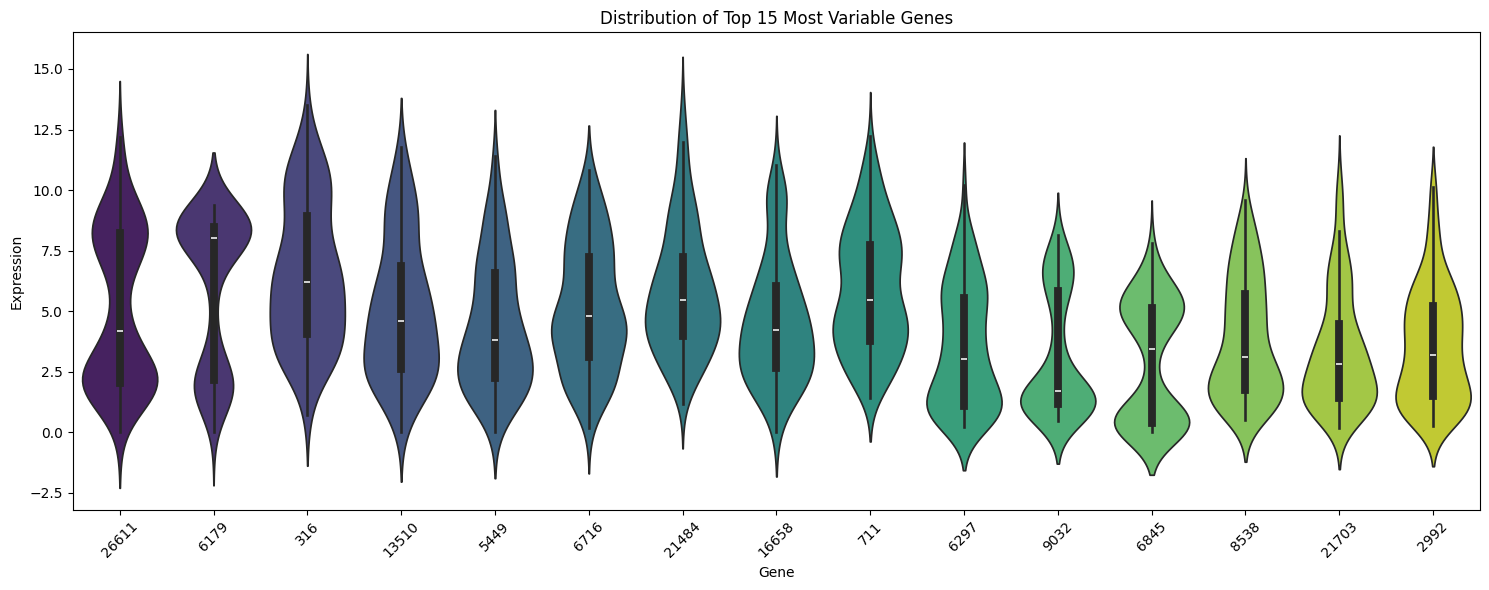

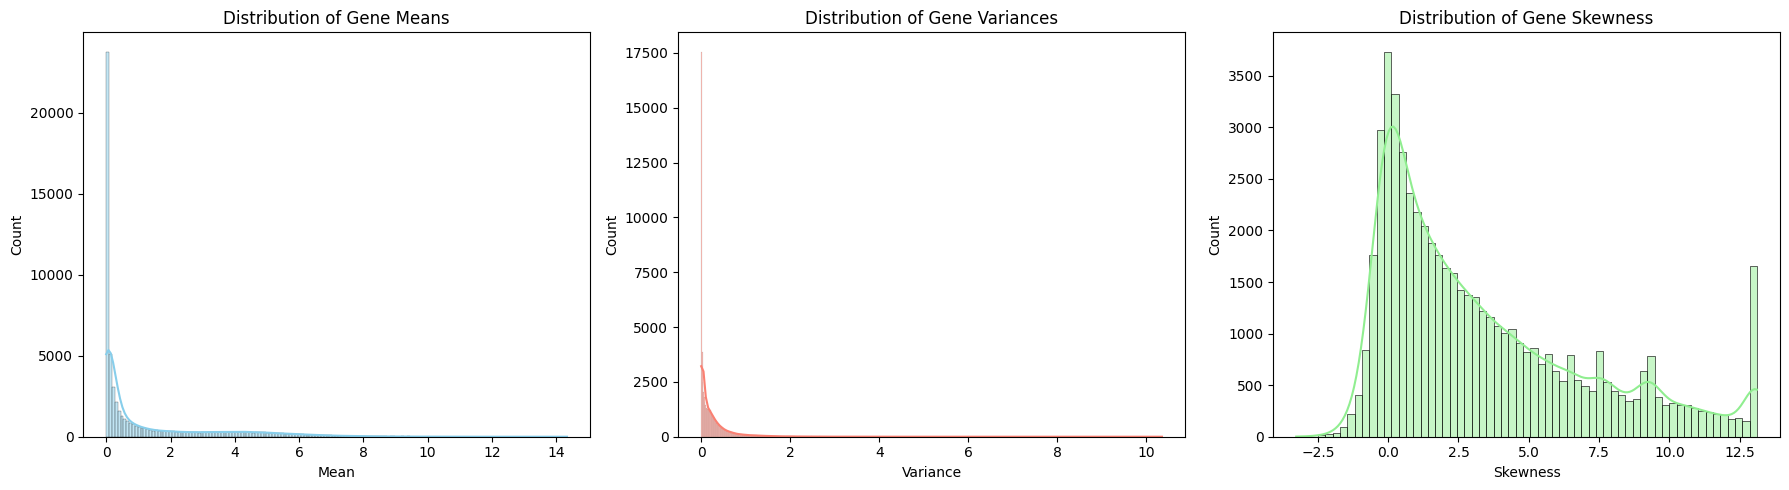

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew


def process_gene_data(df):
    """
    Plots distribution statistics.
    """
    # 1. Calculate Top K Variance Filter (Top 15)
    variances = df.var().sort_values(ascending=False)
    top_15_genes = variances.head(15).index
    df_top_15 = df[top_15_genes]
    
    # 2. Violin Plot for Top 15 Most Variable Genes
    plt.figure(figsize=(15, 6))
    # Melting the dataframe makes it compatible with Seaborn's categorical plotting
    df_melted = df_top_15.melt(var_name='Gene', value_name='Expression')
    sns.violinplot(data=df_melted, x='Gene', y='Expression', hue='Gene', palette='viridis', legend=False)
    plt.xticks(rotation=45)
    plt.title('Distribution of Top 15 Most Variable Genes')
    plt.tight_layout()
    plt.show()

    # 3. Calculate Global Statistics for all 175 genes
    stats_df = pd.DataFrame({
        'Mean': df.mean(),
        'Variance': df.var(),
        'Skewness': df.apply(lambda x: skew(x))
    })

    # 4. Plot Histograms for Mean, Variance, and Skewness
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Mean Histogram
    sns.histplot(stats_df['Mean'], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title('Distribution of Gene Means')

    # Variance Histogram
    sns.histplot(stats_df['Variance'], kde=True, ax=axes[1], color='salmon')
    axes[1].set_title('Distribution of Gene Variances')

    # Skewness Histogram
    sns.histplot(stats_df['Skewness'], kde=True, ax=axes[2], color='lightgreen')
    axes[2].set_title('Distribution of Gene Skewness')

    plt.tight_layout()
    plt.show()

    return stats_df

# Execute the analysis
stats_summary = process_gene_data(X)


The results present interesting insight into the dataframe. As we can see from the generated **top 15 most variable features violin plot representation**, the most variable gene expressions contain interesting distributions which will undoubtedly ease the clustering process through various unsupervised learning means; as we can see, the most variable gene expressions contain interesting distributions, such as the `26611` expression, which has what appears to be a bimodal distribution across patient samples. Furthermore, we can also observe that the **Y-axis scale** shows values ranging from -2 to 15, revealing evidence that ensures a previous expectation about the data, it has already been log-transformed using the **TPM (Transcripts per Million)** by the **GDC (Genomic Data Commons)**, which is a preprocessing pipeline used for the purpose of calculating gene expression comparisons between tumor types (GBM in this case), ensuring that the gene expression transcripts stay the same across samples.

As for the histograms, they absolutely capture the reality of transcriptomic data, specifically the massive spikes at 0 for mean and variance. This is likely due to the dataset containing 60,660 gene expressions for each patient sample and the nature of the dataset; a gladioblastoma tumor cell doesn't express in its variability and mean the diverse range of gene expressions not related to GBM. Therefore, it is safe to assume this represents that most of the gene expressions are "turned off" in the context of this dataset. As for the skewness graph, we can assume that the right-skewness represents gene expression data for patients who underwent gene expression mutation due to their ailment, which asserts even further evidence that while not over-represented, clusters based on specific gene expression mutations are sure to be found across the sample.

Now then, in regards to the detection of potential outliers, by definition, Transcripts Per Million datasets **represent a proportion out of a million** for gene expressions (Zhao, et al., 2020), therefore in regards to technical outliers which may happen due to the processing TPM pipeline failing, the following code will check if every patient's total gene expression features sum to 1,000,000; in the case it does not, it is safe to assume that sequencing data was corrupted during the *alignment or quantification phases* (NIH, 2026) of the STAR-TPM pipeline procedure, which surely lead to technical outliers. Detecting outliers using standard detection conventions may lead to finding extreme gene expression feature mutations which don't pertain to, for example, the standard *Interquartile Range* for that specific feature, which might lead to the deletion of crucial data which might offer an advantage in clustering the present dataset efficiently.

In [6]:
import pandas as pd
import numpy as np

# 1. Reverse the log transformation to get raw TPM values
# (Applies 2^x - 1 to the entire dataframe)
raw_tpm_df = (2 ** X) - 1

# 2. Calculate the total sum of TPMs for each patient
# axis=1 ensures we are summing horizontally across all 60,660 genes per row
patient_tpm_sums = raw_tpm_df.sum(axis=1)

# 3. Define the heuristic bounds
expected_sum = 1000000
tolerance = 100 # Allows for 999,900 to 1,000,100 due to float math rounding

# 4. Filter for outliers (samples that fall outside the tolerance window)
failed_samples = patient_tpm_sums[
    (patient_tpm_sums < expected_sum - tolerance) | 
    (patient_tpm_sums > expected_sum + tolerance)
]

# 5. Output the results
print(f"Total samples checked: {len(patient_tpm_sums)}")
print(f"Corrupted samples found: {len(failed_samples)}")

if len(failed_samples) > 0:
    print("\nWARNING: The following patients failed the TPM heuristic and should be dropped:")
    print(failed_samples)
else:
    print("\nSUCCESS: All patients passed the TPM heuristic (~1,000,000 sum).")
    
    # Optional: Print the first 5 just to visually confirm they hover around 1 million
    print("\nSample Sums:")
    print(patient_tpm_sums.head())

Total samples checked: 175
Corrupted samples found: 0

SUCCESS: All patients passed the TPM heuristic (~1,000,000 sum).

Sample Sums:
0    1.000000e+06
1    1.000000e+06
2    1.000000e+06
3    1.000000e+06
4    1.000000e+06
dtype: float64


As we can see, every one of the patient samples has been processed and presented through rigorous measures, and as such, no technical outliers were found. This was to be expected considering the extensive use of this dataset in the bioinformatic research field. Understanding the underlying complexity and statistical components which constitute the dataset has now given us a clear view of the nature of the data, and now that we understand the data has been processed adequately and that there are indeed interesting conventions regarding the nature of the present features in the dataset, we now proceed to the **feature engineering** phase of the project. 

References:

Zhao S, Ye Z, Stanton R. Misuse of RPKM or TPM normalization when comparing across samples and sequencing protocols. RNA. 2020 Aug;26(8):903-909. doi: 10.1261/rna.074922.120. Epub 2020 Apr 13. PMID: 32284352; PMCID: PMC7373998.
https://docs-gdc-cancer-gov.translate.goog/Data/Bioinformatics_Pipelines/Expression_mRNA_Pipeline/?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc